# Network Science Assignment 4

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 21. October 2024

In [413]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm


## Task 1

Consider Erdős‑Rényi G(N,p) model. Generate Erdős‑Rényi graphs with N= 100 nodes for
different edge creation probabilities p∈ [0,1] and plot the probability that a node belongs to the Largest
Connected Component NLCC/N as a function of p and mark with a vertical line the critical probability
pC= 1/N

### Comments
* The provided Erdős‑Rényi returns a nx Graph for improved usability in the subsequent code.


In [414]:
# er_graph takes as input N (the number of nodes) and p (the edge creation probability)

def er_graph(N, p):
    V_comp = [(i, j) for i in range(N) for j in range(i + 1, N) ]
    V_sel = np.random.rand(len(V_comp)) <= p
    V = [V_comp[i] for i in range(len(V_comp)) if V_sel[i]]

    G = nx.Graph()
    G.add_edges_from(V)
    G. add_nodes_from(list(range(N)))
    return G


# Plotting the probability of NLCC/N as a function of p
p = np.logspace(-4,0,100)
graphs_per_p = 100
nodes = 100
prob = np.zeros(100)

for i, pp in enumerate(p):
    for _ in range(graphs_per_p):
        G = er_graph(nodes, pp)
        prob[i] += len(max(nx.connected_components(G), key = len))/nodes
prob = np.divide(prob ,graphs_per_p)


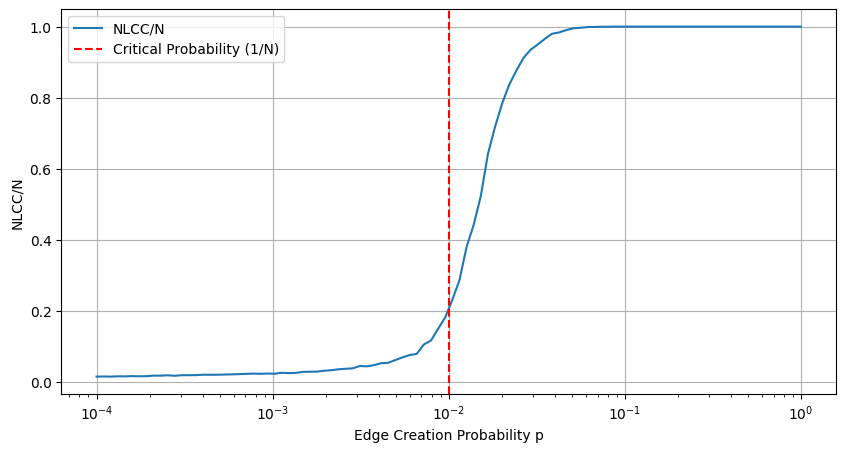

In [415]:
#plotting the probability of NLCC/N as a function of p 
plt.figure(figsize=(10,5))
plt.plot(p, prob, label='NLCC/N')
plt.axvline(1/nodes, color='r', linestyle="--" ,label='Critical Probability (1/N)')
plt.xscale('log')
plt.xlabel('Edge Creation Probability p')
plt.ylabel('NLCC/N')
plt.grid()
plt.legend()
plt.show()


## Task 2
Generate ER graphs with N= 100 nodes for different edge creation probabilities p∈ [0,1] and
plot the average clustering coefficient ⟨c⟩ and the Average Path Length ⟨d⟩ as a function of p. Provide an
interpretation of the result in light of what we discussed during the lecture.

### Comments
* While the clustering coefficient is outlined straight forward in the lecture nodes, multiple interpretations exist for the average path length. 
* Here, the average path length is determined by considering the average path length of the largest connected component. The analysis and rationale for this decision is given in the below interpretation.

In [416]:
c_d_array = np.zeros((100,2))
for i, pp in enumerate(p): 
    for _ in range(graphs_per_p):
        G = er_graph(nodes, pp)
        c_d_array[i][0] += nx.average_clustering(G)

        largest_cc = max(nx.connected_components(G), key=len)
        G_lcc = G.subgraph(largest_cc).copy()
        
        if len(largest_cc) > 1: 
            #c_d_array[i][1] += np.log(nodes)/np.log(sum(dict(nx.degree(G_lcc)).values()))
            c_d_array[i][1] += nx.average_shortest_path_length(G_lcc)
        else:
            c_d_array[i][1] += 0
c_d_array = np.divide(c_d_array, graphs_per_p)


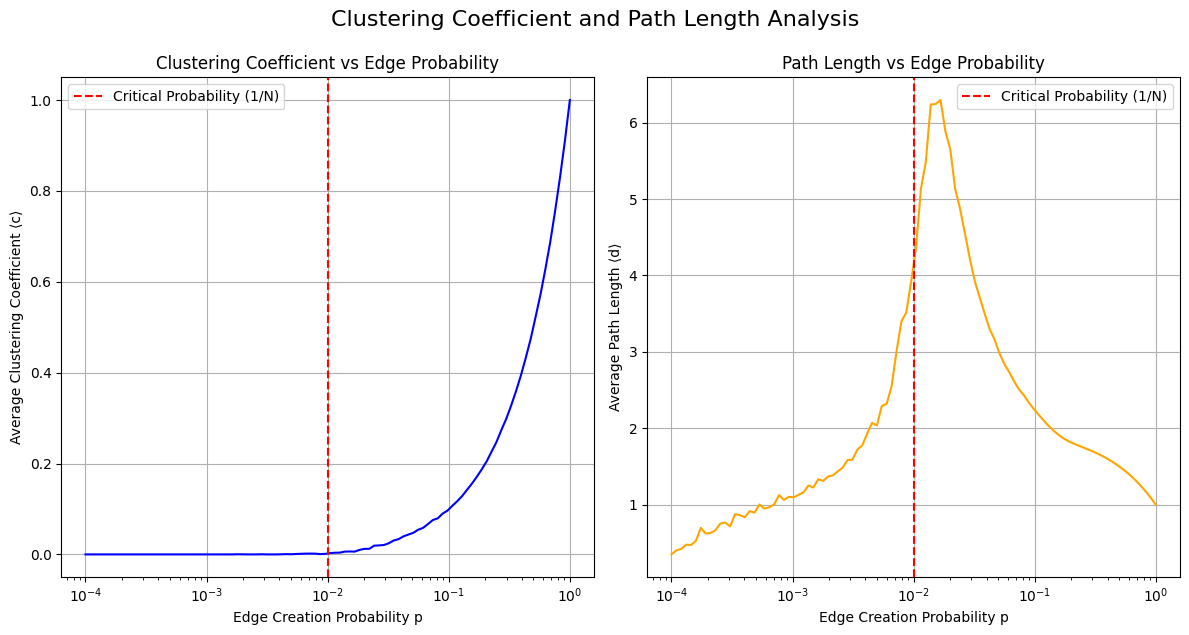

In [417]:
c = c_d_array[:, 0]
d = c_d_array[:, 1]
#plotting the probability of NLCC/N as a function of p 
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes = axes.flatten()

# Plot for clustering coefficient ⟨c⟩
axes[0].plot(p, c, color='blue') 
axes[0].set_xscale('log')
axes[0].axvline(1/nodes, color='r', linestyle="--" ,label='Critical Probability (1/N)')
axes[0].set_xlabel('Edge Creation Probability p')
axes[0].set_ylabel('Average Clustering Coefficient ⟨c⟩')
axes[0].grid()
axes[0].set_title('Clustering Coefficient vs Edge Probability')  
axes[0].legend()

# Plot for path length ⟨d⟩
axes[1].plot(p, d, color='orange') 
axes[1].set_xscale('log')
axes[1].axvline(1/nodes, color='r', linestyle="--" ,label='Critical Probability (1/N)')
axes[1].set_xlabel('Edge Creation Probability p')
axes[1].set_ylabel('Average Path Length ⟨d⟩')
axes[1].grid() 
axes[1].set_title('Path Length vs Edge Probability')  
axes[1].legend()

fig.tight_layout()
fig.suptitle('Clustering Coefficient and Path Length Analysis', fontsize=16, y=1.05)
plt.show()


### Interpretation
* The Erdös-Rényi graph exhibits the clustering structure that was expected, given different edge creation probabilities. With increasing p the the clustering of the network increases. Furthermore, the discussed regimes are visible as well. Especially the transition from subcritical (no giant compontent) to supercritical state is clearly visible after the critical point (1/N).

* As mentioned in the comments to this task above, the average path length was calculated for the largest connected component in each iteration. This is done due to the following rationale:
    - Up until the critical point, no giant component exists, thus the average path length appears a redundant measure in a vastly disconnected graph, since most nodes cannot reach the others. Therefore, we either stipulate the average path length is *inf* or we apply the same rationale as for the rest of the graph. Following the surpassing of the critical point a giant component emerges. This component, by definition, grows proportionally with N, dominating the network. Thus, in combination with clustering coefficient, it proves to be the most insightful measure to calculate the average path length on said component. Once the network switches to a connected regime, this question becomes obsolete, since all components are absorbed by the giant component. As p appraoches one, we further expect the average path length as well as the clustering coefficient to approach 1.
    - In short: the average path length by largest connected component in connection with the clustering coefficient, provides the most insightful information.
* The graph depicting the empirical evidence for the average path length vs. the edge creation probability, is consistent with the aforementioned expectations. Below the critical point, we can expect the largest connected component, to slowly grow, while its connectivity remains sparse; i.e. the LCC grows, but so does the average path length therein. This is in-line with the subcritical regime. As we surpass the critical point we would expect a shift in the regime, such that the largest connected component becomes a giant component the becomes more densly connected the greater p gets. Again the empirical evidence above is consistent with the theoretical expectations. 

## Task 3

Write a function to generate a one‑dimensional lattice with periodic boundary conditions and
coordination number k, defined as we saw in the class and assignment 1. The function should take in
input two parameters:
• N: the number of nodes of the lattice,
• k: the coordination number,
and it should output a network. Finally, produce a visualisation of a network generated using such function, with N= 21 and
k= 5.

In [418]:
def generate_lattice(N, k):
    V = list()

    # we generate the lattice looking "forward"
    for i in range(N):
        for j in range(k):
            V.append((i,(i+j+1)%N))

    return nx.Graph(V)

def plot_circular_graph(G, N, k, p = None):

    # visualisation of the lattice G 
    plt.figure(figsize=(6, 6))

    # converting the graph to a sorted graph for better visualization for watts_strogatz
    if p is not None:
        nodes = list(G.nodes(data=True))
        edges = list(G.edges(data=True))
        G=nx.Graph()
        G.add_nodes_from(sorted(nodes))
        G.add_edges_from(edges)
    
    nx.draw(
        G,
        nx.circular_layout(G),
        with_labels=True,
        node_color='lightblue',
        edge_color='gray'
    )

    if (p is None):
        plt.title(f'1D Lattice (N={N}, k={k})')
    else:
        plt.title(f'1D Lattice (N={N}, k={k}, p={p})')

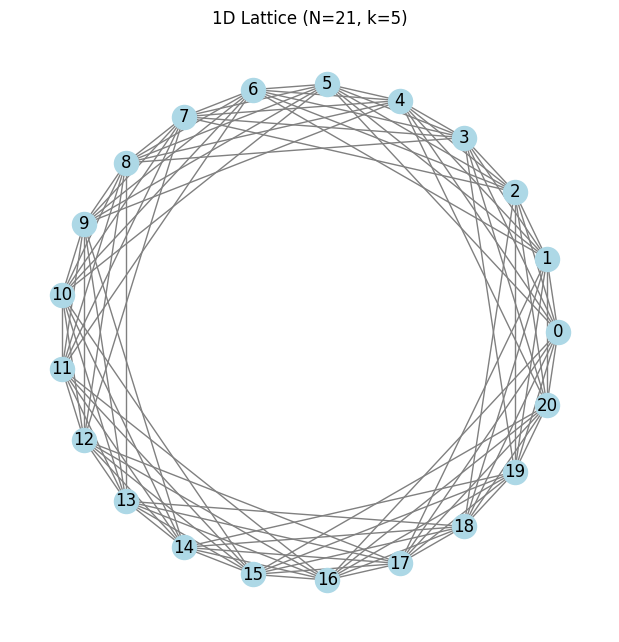

In [419]:
N = 21
k = 5

G = generate_lattice(N,k)
plot_circular_graph(G, N, k)

## Task 4

Compute the Average Path Length ⟨d⟩ of a sequence of one‑dimensional periodic lattices where
k= 10 is fixed and on the number of nodes N ranges between 50 and 1000. Then plot ⟨d⟩ as a function
of N. What is the relation between the ⟨d⟩ and N? Comment the plot.

Text(0.5, 1.0, 'Average Path Length vs Number of Nodes in 1D Lattice')

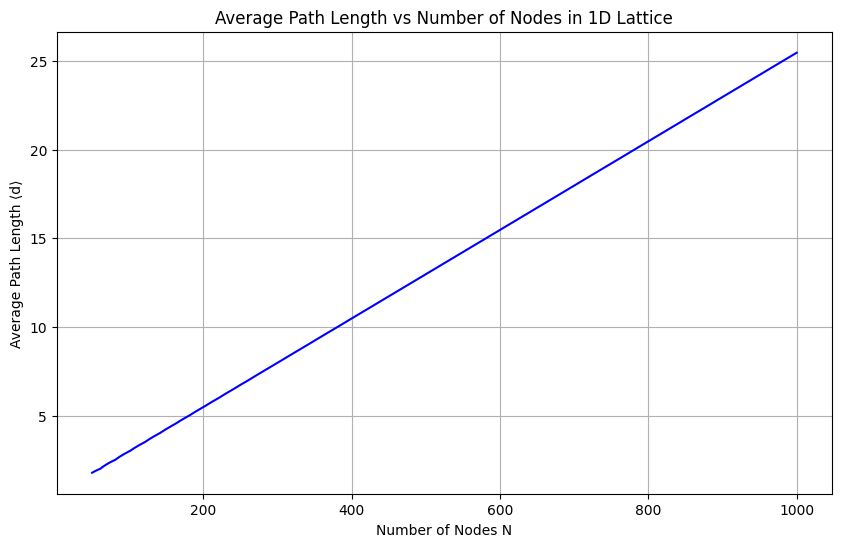

In [420]:
nodes = range(50,1001,1)

avgPathL = np.zeros(len(nodes))

for n in nodes: 
    G = generate_lattice(n,10)
    avgPathL[n-50] += nx.average_shortest_path_length(G)

# plot d as a function of N
plt.figure(figsize=(10, 6))
plt.plot(nodes, avgPathL, color='blue')
plt.xlabel('Number of Nodes N')
plt.ylabel('Average Path Length ⟨d⟩')
plt.grid()
plt.title('Average Path Length vs Number of Nodes in 1D Lattice')

### Interpretation 
As the number of nodes N increases (with constant k), so does the average path length. This can be understood both intuitively as well as analytically. As the number of nodes increases in a ring lattice, but the number of connections of each node to its neighbors stays constant, the average path to each other node must increase since no single node has changed its degree. Looking back at assignment one, we can use the formula derived in task 6 as an approximation:
- ⟨d⟩ = (n - 1 + 2k)/(4k); note: this is only the exact solution for even n and n-1 divisible by 2k, yet it can serves as an approximation.
Since k remains constant, as the nodes N increase, so must the average path length ⟨d⟩


## Task 5

Implement the original Watts‑Strogatz model, following the example we saw in the slides. It should take in input three parameters:
* N: the number of nodes of the network,
* k: the coordination number of the 1‑d original lattice with periodic condition,
* p: the rewiring probability,

and it should output a network. Finally, plot the network generated using such a function, for N= 21,p=0.1,k= 5, using a circular layout


### Comments

* Watts Strogatz is implemented such that no self-loops or multi-edges are created, i.e the network stays connected

In [421]:
def watts_strogatz(N, k, p):
    # we don't use generate_lattice from task 1 on purpose, in order not to use a nx Graph within the watts_strogatz function (as required by the task)
    # 1-d lattice
    V = list()

    for i in range(N):
        for j in range(k):
            V.append((i,(i+j+1)%N)) 
    
    for idx_e in range(len(V)):
        if np.random.rand() <= p:
            cont = False
            # we look for an edge to swap until we find one
            while not cont:
                idx_ee = np.random.choice(len(V))
                if idx_ee == idx_e:
                    continue 

                i, j = V[idx_e]
                k, l = V[idx_ee]

                # Ensure no self-loops and no parallel multi-edges
                if i != k and j != l and (i, k) not in V and (k, i) not in V and (j, l) not in V and (l, j) not in V:
                    V[idx_e] = (i, k)
                    V[idx_ee] = (j, l)
                    cont = True 


    return nx.Graph(V)



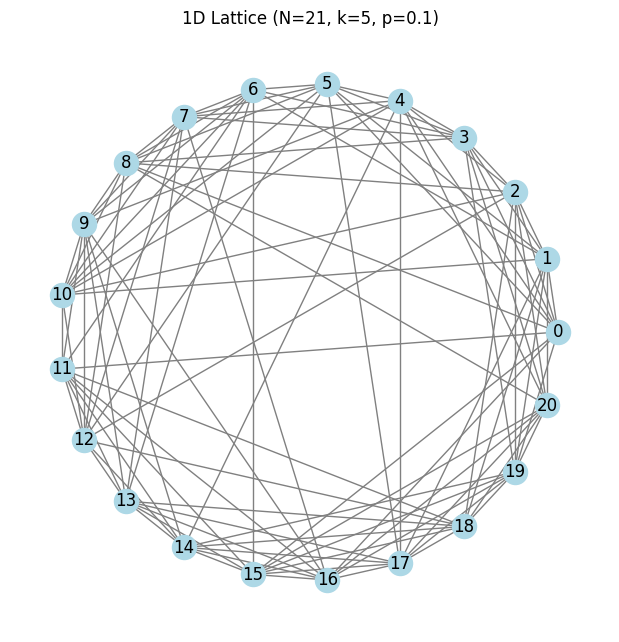

In [422]:
N = 21
k = 5
p = 0.1

G = watts_strogatz(N, k, p)
plot_circular_graph(G, N, k, p)

## Task 6
Compute and plot together ⟨d⟩ and c, the global clustering coefficient, on a sample of networks
generated from the Watts‑Strogatz model (using the python function you wrote in the previous point), as
a function of p ∈ [0,1](the rewiring parameter), keeping N= 1000 and k= 10 fixed. Normalize the value
using the clustering and Average Path Distance of a one‑dimensional lattice with parameters N= 1000
and k= 10, to obtain a plot similar to the one in Watts and Strogatz [1998].

In [423]:
N = 1000
k = 10
n_p = 100
p = np.logspace(-4,0,n_p)
samples = 20

c_d_array = np.zeros((n_p,2))

for i in tqdm(range(n_p), desc="Progress"):
    for j in range(samples):
        G = watts_strogatz(N, k, p[i])
        c_d_array[i][0] += nx.average_clustering(G)
        c_d_array[i][1] += nx.average_shortest_path_length(G)

c_d_array = np.divide(c_d_array, samples)

Progress: 100%|██████████| 100/100 [1:28:34<00:00, 53.14s/it]  


In [424]:
# Perform normalization
c_d_array_norm = (c_d_array - c_d_array.min(axis=0)) / (c_d_array.max(axis=0) - c_d_array.min(axis=0))

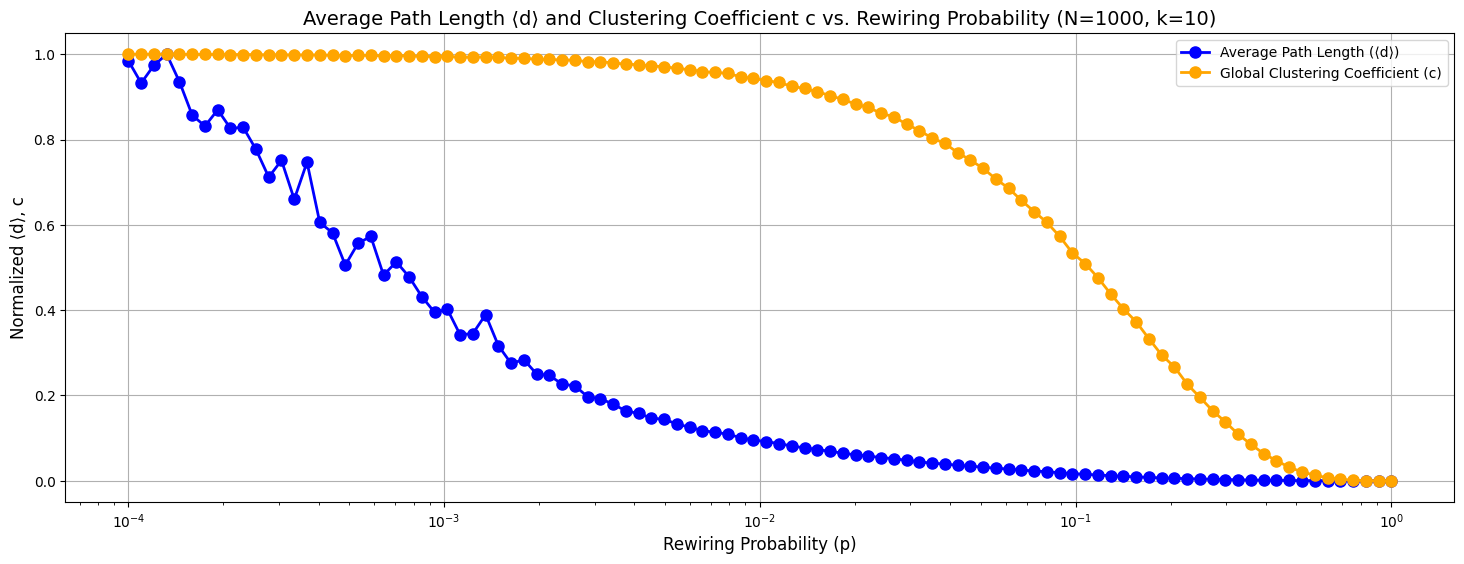

In [425]:
plt.figure(figsize=(15, 6))
plt.title(r"Average Path Length ⟨d⟩ and Clustering Coefficient c vs. Rewiring Probability (N=1000, k=10)", fontsize=14)
plt.plot(p, c_d_array_norm[:,1], marker='o', color='blue', markersize=8, linewidth=2, label='Average Path Length (⟨d⟩)')
plt.plot(p, c_d_array_norm[:,0], color='orange', marker='o', markersize=8, linewidth=2, label='Global Clustering Coefficient (c)')
plt.xlabel('Rewiring Probability (p)', fontsize=12)
plt.xscale('log')
plt.ylabel('Normalized ⟨d⟩, c', fontsize=12)
plt.legend()
plt.grid()
plt.tight_layout(pad=2)